# HW10-11 – Компьютерное зрение в PyTorch: CNN, Transfer Learning, Segmentation

В этом ноутбуке реализованы:
- **Часть A (S10)**: Классификация изображений на датасете STL10 с экспериментами C1-C4 (простая CNN, аугментации, transfer learning с ResNet18)
- **Часть B (S11)**: Сегментация на датасете OxfordIIITPet с pretrained DeepLabV3 и двумя режимами постобработки (V1, V2)

## 1. Импорты, seed и устройство

In [1]:
import json
import csv
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F
from scipy import ndimage

# Фиксируем seed для воспроизводимости
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.8.0


## 2. Подготовка артефактов

In [2]:
# Создаём папки для артефактов
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
artifacts_dir.mkdir(exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Пути к файлам артефактов
RUNS_CSV = artifacts_dir / "runs.csv"
BEST_CLASSIFIER_PATH = artifacts_dir / "best_classifier.pt"
BEST_CLASSIFIER_CONFIG_PATH = artifacts_dir / "best_classifier_config.json"

# Путь к данным
data_root = Path("data")
data_root.mkdir(exist_ok=True)

print(f"Artifacts will be saved to: {artifacts_dir.absolute()}")

Artifacts will be saved to: /Users/v.razon/Desktop/вуз/ml/mirea-aie-project/homeworks/HW10-11/artifacts


## 3. Часть A: Данные STL10 для классификации

In [3]:
# Константы для STL10
STL10_NUM_CLASSES = 10
STL10_IMAGE_SIZE = 96
BATCH_SIZE = 64

# ImageNet статистики для нормализации
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Базовый transform для простой CNN (без аугментаций)
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transform с аугментациями для простой CNN
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transform для ResNet (resize до 224x224)
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transform для ResNet с аугментациями
transform_resnet_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transforms defined successfully")

Transforms defined successfully


In [4]:
# Загружаем STL10
# STL10 имеет split='train' (5000 изображений) и split='test' (8000 изображений)

train_full_stl10 = datasets.STL10(
    root=data_root,
    split='train',
    download=True,
    transform=transform_base
)

test_ds_stl10 = datasets.STL10(
    root=data_root,
    split='test',
    download=True,
    transform=transform_base
)

# Разбиваем train на train/val (80/20)
val_frac = 0.2
n_train = int((1 - val_frac) * len(train_full_stl10))
n_val = len(train_full_stl10) - n_train

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(
    range(len(train_full_stl10)), 
    [n_train, n_val], 
    generator=generator
)

# Сохраняем индексы для использования с разными transforms
train_indices_list = list(train_indices)
val_indices_list = list(val_indices)

print(f"STL10 classes: {train_full_stl10.classes}")
print(f"Number of classes: {STL10_NUM_CLASSES}")
print(f"Train size: {n_train}, Val size: {n_val}, Test size: {len(test_ds_stl10)}")

STL10 classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Number of classes: 10
Train size: 4000, Val size: 1000, Test size: 8000


In [5]:
def create_stl10_loaders(train_transform, val_transform, test_transform, batch_size=BATCH_SIZE):
    """
    Создаёт DataLoader-ы для STL10 с заданными transforms.
    """
    # Создаём датасеты с нужными transforms
    train_ds = datasets.STL10(root=data_root, split='train', transform=train_transform)
    val_ds = datasets.STL10(root=data_root, split='train', transform=val_transform)
    test_ds = datasets.STL10(root=data_root, split='test', transform=test_transform)
    
    # Используем Subset с сохранёнными индексами
    train_subset = Subset(train_ds, train_indices_list)
    val_subset = Subset(val_ds, val_indices_list)
    
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    
    return train_loader, val_loader, test_loader

# Sanity check с базовым transform
train_loader_check, val_loader_check, test_loader_check = create_stl10_loaders(
    transform_base, transform_base, transform_base
)

x_batch, y_batch = next(iter(train_loader_check))
print(f"Batch shape: {x_batch.shape}")
print(f"Labels shape: {y_batch.shape}")
print(f"Value range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

Batch shape: torch.Size([64, 3, 96, 96])
Labels shape: torch.Size([64])
Value range: [-2.118, 2.640]


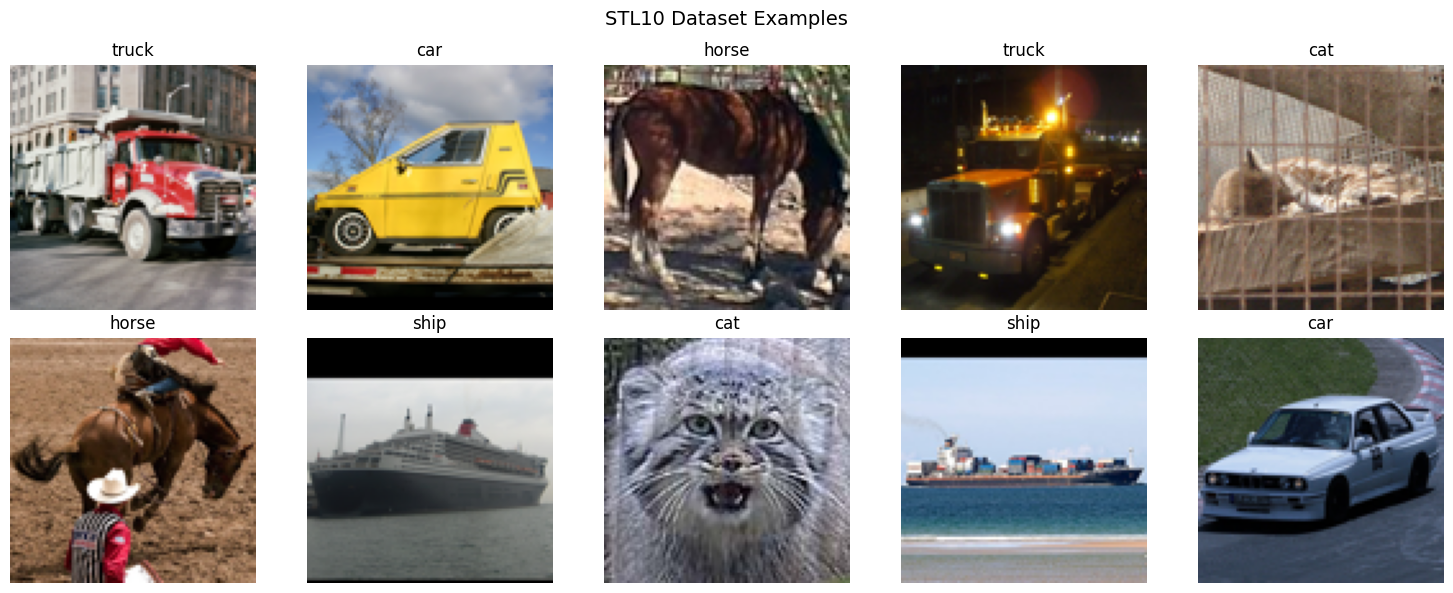

In [6]:
# Визуализация примеров из STL10
def denormalize(img, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Обратная нормализация для визуализации."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img * std + mean

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
class_names = train_full_stl10.classes

for i, (img, label) in enumerate(train_loader_check):
    if i >= 10:
        break
    ax = axes[i // 5, i % 5]
    img_show = denormalize(img[0]).permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0, 1)
    ax.imshow(img_show)
    ax.set_title(class_names[label[0].item()])
    ax.axis('off')

plt.suptitle('STL10 Dataset Examples', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Визуализация аугментаций

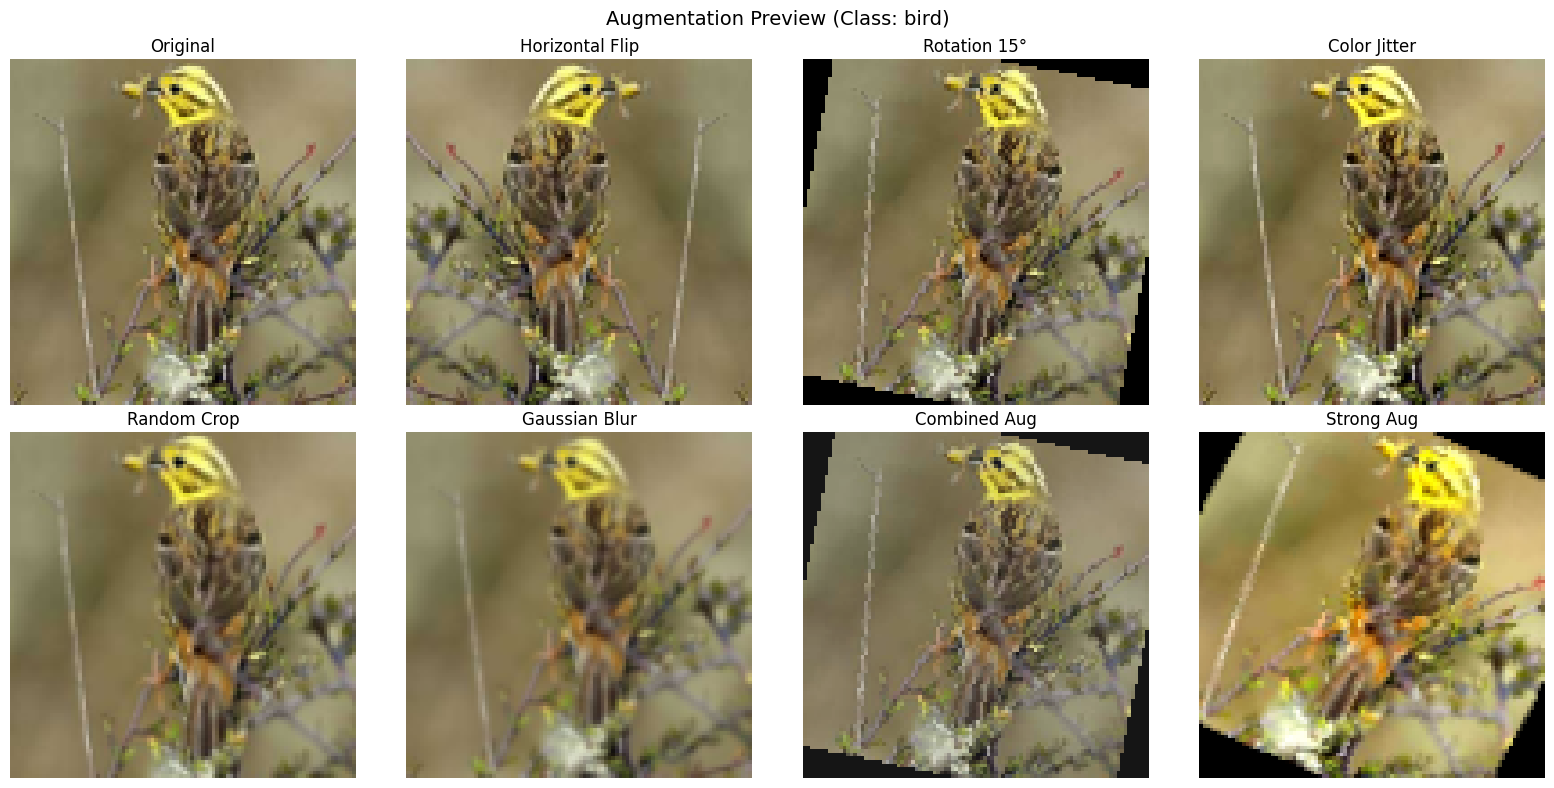

Saved: artifacts/figures/augmentations_preview.png


In [7]:
# Визуализация эффекта аугментаций на одном изображении
# Загружаем одно изображение без transform
raw_ds = datasets.STL10(root=data_root, split='train', transform=None)
sample_img, sample_label = raw_ds[0]

# Применяем разные аугментации
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Оригинал
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Разные аугментации
aug_transforms = [
    ('Horizontal Flip', transforms.RandomHorizontalFlip(p=1.0)),
    ('Rotation 15°', transforms.RandomRotation(degrees=15)),
    ('Color Jitter', transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)),
    ('Random Crop', transforms.RandomResizedCrop(96, scale=(0.8, 1.0))),
    ('Gaussian Blur', transforms.GaussianBlur(kernel_size=5)),
    ('Combined Aug', transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2)
    ])),
    ('Strong Aug', transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
        transforms.RandomResizedCrop(96, scale=(0.7, 1.0))
    ]))
]

for idx, (name, aug) in enumerate(aug_transforms):
    row = (idx + 1) // 4
    col = (idx + 1) % 4
    aug_img = aug(sample_img)
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(name)
    axes[row, col].axis('off')

plt.suptitle(f'Augmentation Preview (Class: {class_names[sample_label]})', fontsize=14)
plt.tight_layout()
plt.savefig(figures_dir / 'augmentations_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {figures_dir / 'augmentations_preview.png'}")

## 5. Модели для классификации

In [8]:
class SimpleCNN(nn.Module):
    """
    Простая CNN для классификации STL10 (96x96 изображения).
    Архитектура:
    - Conv(3->32, 3x3, padding=1) -> ReLU -> MaxPool(2): 96->48
    - Conv(32->64, 3x3, padding=1) -> ReLU -> MaxPool(2): 48->24
    - Conv(64->128, 3x3, padding=1) -> ReLU -> MaxPool(2): 24->12
    - Flatten -> Linear(128*12*12, 256) -> ReLU -> Dropout -> Linear(256, num_classes)
    """
    def __init__(self, num_classes=10, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Conv block 1: 96x96 -> 48x48
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv block 2: 48x48 -> 24x24
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Conv block 3: 24x24 -> 12x12
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def create_resnet18_head_only(num_classes=10):
    """
    ResNet18 с замороженным backbone, обучается только fc layer.
    """
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # Замораживаем все параметры
    for param in model.parameters():
        param.requires_grad = False

    # Заменяем последний слой
    model.fc = nn.Linear(512, num_classes)

    return model


def create_resnet18_finetune(num_classes=10):
    """
    ResNet18 с частичным fine-tuning: обучаются layer4 и fc.
    """
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # Замораживаем все параметры
    for param in model.parameters():
        param.requires_grad = False

    # Размораживаем layer4 и fc
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Заменяем последний слой (он автоматически будет trainable)
    model.fc = nn.Linear(512, num_classes)

    return model


# Проверка моделей
test_input = torch.randn(2, 3, 96, 96)
test_input_224 = torch.randn(2, 3, 224, 224)

model_cnn = SimpleCNN(num_classes=STL10_NUM_CLASSES)
model_resnet_head = create_resnet18_head_only(num_classes=STL10_NUM_CLASSES)
model_resnet_ft = create_resnet18_finetune(num_classes=STL10_NUM_CLASSES)

print(f"SimpleCNN output shape: {model_cnn(test_input).shape}")
print(f"ResNet18 head-only output shape: {model_resnet_head(test_input_224).shape}")
print(f"ResNet18 finetune output shape: {model_resnet_ft(test_input_224).shape}")

# Подсчёт trainable параметров
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTrainable parameters:")
print(f"  SimpleCNN: {count_trainable_params(model_cnn):,}")
print(f"  ResNet18 head-only: {count_trainable_params(model_resnet_head):,}")
print(f"  ResNet18 finetune: {count_trainable_params(model_resnet_ft):,}")

SimpleCNN output shape: torch.Size([2, 10])
ResNet18 head-only output shape: torch.Size([2, 10])
ResNet18 finetune output shape: torch.Size([2, 10])

Trainable parameters:
  SimpleCNN: 4,814,666
  ResNet18 head-only: 5,130
  ResNet18 finetune: 8,398,858


## 6. Функции обучения и оценки

In [9]:
def accuracy_from_logits(logits, targets):
    """Вычисляет accuracy из logits."""
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device):
    """Обучает модель одну эпоху."""
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return running_loss / n_batches, running_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Оценивает модель на валидации/тесте."""
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        
        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return running_loss / n_batches, running_acc / n_batches


print("Training functions defined.")

Training functions defined.


In [10]:
def log_to_csv(experiment_id, task, dataset, seed, model_summary, optimizer_name, lr, 
               epochs_trained, best_val_accuracy, test_accuracy=None, 
               precision=None, recall=None, mean_iou=None, notes=""):
    """Записывает результаты эксперимента в runs.csv."""
    is_new_file = not RUNS_CSV.exists()
    
    with RUNS_CSV.open('a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        if is_new_file:
            writer.writerow([
                'experiment_id', 'task', 'dataset', 'seed', 'model_summary',
                'optimizer', 'lr', 'epochs_trained', 'best_val_accuracy',
                'test_accuracy', 'precision', 'recall', 'mean_iou', 'notes'
            ])
        writer.writerow([
            experiment_id, task, dataset, seed, model_summary,
            optimizer_name, lr, epochs_trained, best_val_accuracy,
            test_accuracy, precision, recall, mean_iou, notes
        ])


def run_classification_experiment(
    experiment_id,
    model,
    train_loader,
    val_loader,
    optimizer_name="Adam",
    lr=1e-3,
    max_epochs=15,
    dataset_name="STL10",
    model_summary="",
    save_best_model=False,
    notes=""
):
    """
    Запускает один эксперимент классификации.
    Возвращает обученную модель и историю.
    """
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    best_state = None
    
    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        print(f"[{experiment_id}] Epoch {epoch}/{max_epochs} | "
              f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f} | "
              f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")
    
    # Загружаем лучшее состояние
    if best_state is not None:
        model.load_state_dict(best_state)
    
    # Логируем в CSV
    log_to_csv(
        experiment_id=experiment_id,
        task='classification',
        dataset=dataset_name,
        seed=SEED,
        model_summary=model_summary,
        optimizer_name=optimizer_name,
        lr=lr,
        epochs_trained=max_epochs,
        best_val_accuracy=best_val_acc,
        notes=notes
    )
    
    # Сохраняем лучшую модель
    if save_best_model:
        torch.save(model.state_dict(), BEST_CLASSIFIER_PATH)
        config = {
            'experiment_id': experiment_id,
            'dataset': dataset_name,
            'seed': SEED,
            'model_summary': model_summary,
            'optimizer': optimizer_name,
            'lr': lr,
            'batch_size': BATCH_SIZE,
            'max_epochs': max_epochs,
            'best_val_accuracy': best_val_acc,
            'notes': notes
        }
        BEST_CLASSIFIER_CONFIG_PATH.write_text(
            json.dumps(config, indent=2, ensure_ascii=False),
            encoding='utf-8'
        )
        print(f"Saved best model to {BEST_CLASSIFIER_PATH}")
    
    return model, history, best_val_acc


print("Experiment functions defined.")

Experiment functions defined.


## 7. Эксперименты C1-C4 (Часть A)

In [11]:
# Удаляем старый runs.csv если есть
if RUNS_CSV.exists():
    RUNS_CSV.unlink()
    print("Removed old runs.csv")

# Словарь для хранения результатов
results = {}
histories = {}

Removed old runs.csv


In [12]:
# C1: Простая CNN без аугментаций
print("="*60)
print("C1: SimpleCNN без аугментаций")
print("="*60)

train_loader_c1, val_loader_c1, _ = create_stl10_loaders(
    transform_base, transform_base, transform_base
)

model_c1 = SimpleCNN(num_classes=STL10_NUM_CLASSES)
model_c1, hist_c1, best_val_c1 = run_classification_experiment(
    experiment_id='C1',
    model=model_c1,
    train_loader=train_loader_c1,
    val_loader=val_loader_c1,
    optimizer_name='Adam',
    lr=1e-3,
    max_epochs=15,
    model_summary='SimpleCNN: Conv(3->32->64->128), FC(256), no augmentation',
    notes='Baseline CNN without augmentation'
)

results['C1'] = best_val_c1
histories['C1'] = hist_c1
print(f"\nC1 best val accuracy: {best_val_c1:.4f}")

C1: SimpleCNN без аугментаций
[C1] Epoch 1/15 | train_loss=1.9333, val_loss=1.5579 | train_acc=0.2728, val_acc=0.4285
[C1] Epoch 2/15 | train_loss=1.5353, val_loss=1.4288 | train_acc=0.4258, val_acc=0.4766
[C1] Epoch 3/15 | train_loss=1.3487, val_loss=1.2939 | train_acc=0.5047, val_acc=0.5330
[C1] Epoch 4/15 | train_loss=1.1917, val_loss=1.2362 | train_acc=0.5595, val_acc=0.5572
[C1] Epoch 5/15 | train_loss=1.0554, val_loss=1.2158 | train_acc=0.6131, val_acc=0.5637
[C1] Epoch 6/15 | train_loss=0.9342, val_loss=1.1594 | train_acc=0.6550, val_acc=0.6055
[C1] Epoch 7/15 | train_loss=0.7845, val_loss=1.1713 | train_acc=0.7210, val_acc=0.6068
[C1] Epoch 8/15 | train_loss=0.6496, val_loss=1.1997 | train_acc=0.7661, val_acc=0.6039
[C1] Epoch 9/15 | train_loss=0.5474, val_loss=1.2778 | train_acc=0.8058, val_acc=0.6010
[C1] Epoch 10/15 | train_loss=0.4669, val_loss=1.2687 | train_acc=0.8291, val_acc=0.6207
[C1] Epoch 11/15 | train_loss=0.3395, val_loss=1.3309 | train_acc=0.8822, val_acc=0.6270


In [13]:
# C2: Простая CNN с аугментациями
print("="*60)
print("C2: SimpleCNN с аугментациями")
print("="*60)

train_loader_c2, val_loader_c2, _ = create_stl10_loaders(
    transform_aug, transform_base, transform_base
)

model_c2 = SimpleCNN(num_classes=STL10_NUM_CLASSES)
model_c2, hist_c2, best_val_c2 = run_classification_experiment(
    experiment_id='C2',
    model=model_c2,
    train_loader=train_loader_c2,
    val_loader=val_loader_c2,
    optimizer_name='Adam',
    lr=1e-3,
    max_epochs=15,
    model_summary='SimpleCNN: Conv(3->32->64->128), FC(256), with augmentation',
    notes='CNN with HorizontalFlip, Rotation, ColorJitter'
)

results['C2'] = best_val_c2
histories['C2'] = hist_c2
print(f"\nC2 best val accuracy: {best_val_c2:.4f}")

C2: SimpleCNN с аугментациями
[C2] Epoch 1/15 | train_loss=2.0076, val_loss=1.6522 | train_acc=0.2542, val_acc=0.3559
[C2] Epoch 2/15 | train_loss=1.6564, val_loss=1.5645 | train_acc=0.3688, val_acc=0.4293
[C2] Epoch 3/15 | train_loss=1.5570, val_loss=1.4831 | train_acc=0.4162, val_acc=0.4439
[C2] Epoch 4/15 | train_loss=1.4511, val_loss=1.3308 | train_acc=0.4506, val_acc=0.4914
[C2] Epoch 5/15 | train_loss=1.3550, val_loss=1.3296 | train_acc=0.4980, val_acc=0.4918
[C2] Epoch 6/15 | train_loss=1.3075, val_loss=1.2860 | train_acc=0.5161, val_acc=0.5279
[C2] Epoch 7/15 | train_loss=1.2305, val_loss=1.2188 | train_acc=0.5501, val_acc=0.5574
[C2] Epoch 8/15 | train_loss=1.1746, val_loss=1.2278 | train_acc=0.5588, val_acc=0.5545
[C2] Epoch 9/15 | train_loss=1.1410, val_loss=1.1992 | train_acc=0.5751, val_acc=0.5529
[C2] Epoch 10/15 | train_loss=1.1316, val_loss=1.1943 | train_acc=0.5903, val_acc=0.5562
[C2] Epoch 11/15 | train_loss=1.1209, val_loss=1.1118 | train_acc=0.5940, val_acc=0.6045


In [14]:
# C3: ResNet18 head-only (замороженный backbone)
print("="*60)
print("C3: ResNet18 head-only (frozen backbone)")
print("="*60)

train_loader_c3, val_loader_c3, _ = create_stl10_loaders(
    transform_resnet, transform_resnet, transform_resnet
)

model_c3 = create_resnet18_head_only(num_classes=STL10_NUM_CLASSES)
model_c3, hist_c3, best_val_c3 = run_classification_experiment(
    experiment_id='C3',
    model=model_c3,
    train_loader=train_loader_c3,
    val_loader=val_loader_c3,
    optimizer_name='Adam',
    lr=1e-3,
    max_epochs=15,
    model_summary='ResNet18 pretrained, head-only (fc trainable)',
    notes='Transfer learning: only fc layer trained'
)

results['C3'] = best_val_c3
histories['C3'] = hist_c3
print(f"\nC3 best val accuracy: {best_val_c3:.4f}")

C3: ResNet18 head-only (frozen backbone)
[C3] Epoch 1/15 | train_loss=0.9841, val_loss=0.4314 | train_acc=0.7711, val_acc=0.9086
[C3] Epoch 2/15 | train_loss=0.3455, val_loss=0.2931 | train_acc=0.9303, val_acc=0.9262
[C3] Epoch 3/15 | train_loss=0.2501, val_loss=0.2466 | train_acc=0.9407, val_acc=0.9359
[C3] Epoch 4/15 | train_loss=0.2038, val_loss=0.2241 | train_acc=0.9497, val_acc=0.9379
[C3] Epoch 5/15 | train_loss=0.1798, val_loss=0.2084 | train_acc=0.9526, val_acc=0.9398
[C3] Epoch 6/15 | train_loss=0.1596, val_loss=0.2009 | train_acc=0.9588, val_acc=0.9389
[C3] Epoch 7/15 | train_loss=0.1575, val_loss=0.1925 | train_acc=0.9556, val_acc=0.9408
[C3] Epoch 8/15 | train_loss=0.1343, val_loss=0.1904 | train_acc=0.9650, val_acc=0.9428
[C3] Epoch 9/15 | train_loss=0.1286, val_loss=0.1851 | train_acc=0.9638, val_acc=0.9486
[C3] Epoch 10/15 | train_loss=0.1200, val_loss=0.1786 | train_acc=0.9640, val_acc=0.9428
[C3] Epoch 11/15 | train_loss=0.1129, val_loss=0.1745 | train_acc=0.9670, val_

In [15]:
# C4: ResNet18 partial fine-tune (layer4 + fc)
print("="*60)
print("C4: ResNet18 partial fine-tune (layer4 + fc)")
print("="*60)

train_loader_c4, val_loader_c4, _ = create_stl10_loaders(
    transform_resnet_aug, transform_resnet, transform_resnet
)

model_c4 = create_resnet18_finetune(num_classes=STL10_NUM_CLASSES)
model_c4, hist_c4, best_val_c4 = run_classification_experiment(
    experiment_id='C4',
    model=model_c4,
    train_loader=train_loader_c4,
    val_loader=val_loader_c4,
    optimizer_name='Adam',
    lr=1e-4,  # Меньший lr для fine-tuning
    max_epochs=15,
    model_summary='ResNet18 pretrained, partial finetune (layer4 + fc)',
    notes='Transfer learning: layer4 and fc trained, with augmentation'
)

results['C4'] = best_val_c4
histories['C4'] = hist_c4
print(f"\nC4 best val accuracy: {best_val_c4:.4f}")

C4: ResNet18 partial fine-tune (layer4 + fc)
[C4] Epoch 1/15 | train_loss=0.7248, val_loss=0.2764 | train_acc=0.7929, val_acc=0.9143
[C4] Epoch 2/15 | train_loss=0.2342, val_loss=0.2131 | train_acc=0.9288, val_acc=0.9318
[C4] Epoch 3/15 | train_loss=0.1483, val_loss=0.2095 | train_acc=0.9601, val_acc=0.9273
[C4] Epoch 4/15 | train_loss=0.1088, val_loss=0.1990 | train_acc=0.9740, val_acc=0.9338
[C4] Epoch 5/15 | train_loss=0.0816, val_loss=0.2007 | train_acc=0.9804, val_acc=0.9344
[C4] Epoch 6/15 | train_loss=0.0602, val_loss=0.1920 | train_acc=0.9864, val_acc=0.9389
[C4] Epoch 7/15 | train_loss=0.0455, val_loss=0.1855 | train_acc=0.9891, val_acc=0.9402
[C4] Epoch 8/15 | train_loss=0.0384, val_loss=0.1984 | train_acc=0.9931, val_acc=0.9354
[C4] Epoch 9/15 | train_loss=0.0322, val_loss=0.1888 | train_acc=0.9928, val_acc=0.9402
[C4] Epoch 10/15 | train_loss=0.0264, val_loss=0.1924 | train_acc=0.9948, val_acc=0.9367
[C4] Epoch 11/15 | train_loss=0.0234, val_loss=0.1873 | train_acc=0.9950, 

In [16]:
# Выбор лучшего эксперимента и сохранение модели
print("="*60)
print("Результаты экспериментов C1-C4")
print("="*60)

for exp_id, val_acc in results.items():
    print(f"{exp_id}: val_accuracy = {val_acc:.4f}")

best_exp = max(results, key=results.get)
print(f"\nЛучший эксперимент: {best_exp} с val_accuracy = {results[best_exp]:.4f}")

# Пересохраняем лучшую модель
best_model_map = {'C1': model_c1, 'C2': model_c2, 'C3': model_c3, 'C4': model_c4}
best_model = best_model_map[best_exp]

torch.save(best_model.state_dict(), BEST_CLASSIFIER_PATH)

# Определяем model_summary для лучшей модели
model_summaries = {
    'C1': 'SimpleCNN: Conv(3->32->64->128), FC(256), no augmentation',
    'C2': 'SimpleCNN: Conv(3->32->64->128), FC(256), with augmentation',
    'C3': 'ResNet18 pretrained, head-only (fc trainable)',
    'C4': 'ResNet18 pretrained, partial finetune (layer4 + fc)'
}

transforms_info = {
    'C1': {'preprocess': 'ToTensor, Normalize(ImageNet)', 'augmentation': 'none'},
    'C2': {'preprocess': 'ToTensor, Normalize(ImageNet)', 'augmentation': 'HorizontalFlip(0.5), Rotation(15), ColorJitter(0.2,0.2,0.2)'},
    'C3': {'preprocess': 'Resize(224), ToTensor, Normalize(ImageNet)', 'augmentation': 'none'},
    'C4': {'preprocess': 'Resize(224), ToTensor, Normalize(ImageNet)', 'augmentation': 'HorizontalFlip(0.5), Rotation(15), ColorJitter(0.2,0.2,0.2)'}
}

config = {
    'experiment_id': best_exp,
    'dataset': 'STL10',
    'seed': SEED,
    'model_summary': model_summaries[best_exp],
    'optimizer': 'Adam',
    'lr': 1e-4 if best_exp == 'C4' else 1e-3,
    'batch_size': BATCH_SIZE,
    'max_epochs': 15,
    'best_val_accuracy': results[best_exp],
    'image_size': 224 if best_exp in ['C3', 'C4'] else 96,
    'transforms': transforms_info[best_exp]['preprocess'],
    'augmentation': transforms_info[best_exp]['augmentation']
}
BEST_CLASSIFIER_CONFIG_PATH.write_text(
    json.dumps(config, indent=2, ensure_ascii=False),
    encoding='utf-8'
)

print(f"\nСохранена лучшая модель: {BEST_CLASSIFIER_PATH}")
print(f"Сохранён конфиг: {BEST_CLASSIFIER_CONFIG_PATH}")

Результаты экспериментов C1-C4
C1: val_accuracy = 0.6326
C2: val_accuracy = 0.6045
C3: val_accuracy = 0.9486
C4: val_accuracy = 0.9480

Лучший эксперимент: C3 с val_accuracy = 0.9486

Сохранена лучшая модель: artifacts/best_classifier.pt
Сохранён конфиг: artifacts/best_classifier_config.json


## 8. Визуализация результатов классификации

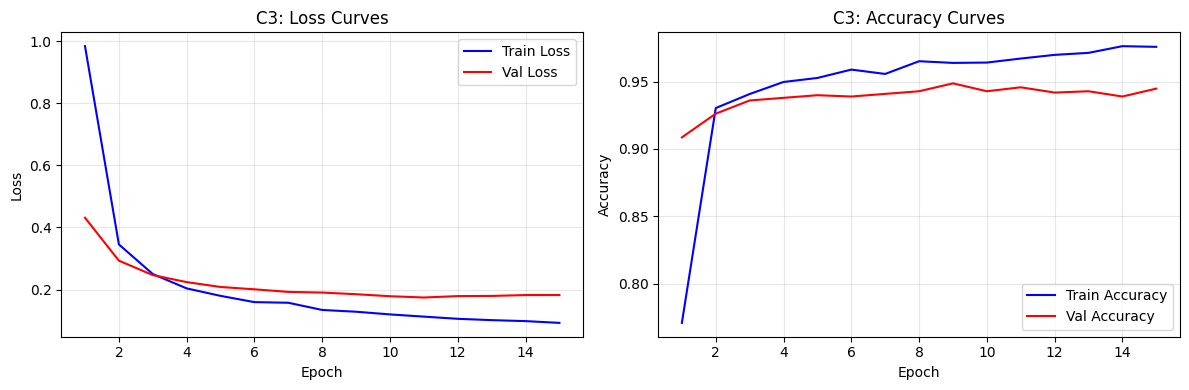

Saved: artifacts/figures/classification_curves_best.png


In [17]:
# График кривых лучшего эксперимента
best_hist = histories[best_exp]
epochs = range(1, len(best_hist['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, best_hist['train_loss'], 'b-', label='Train Loss')
axes[0].plot(epochs, best_hist['val_loss'], 'r-', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'{best_exp}: Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, best_hist['train_acc'], 'b-', label='Train Accuracy')
axes[1].plot(epochs, best_hist['val_acc'], 'r-', label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{best_exp}: Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'classification_curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {figures_dir / 'classification_curves_best.png'}")

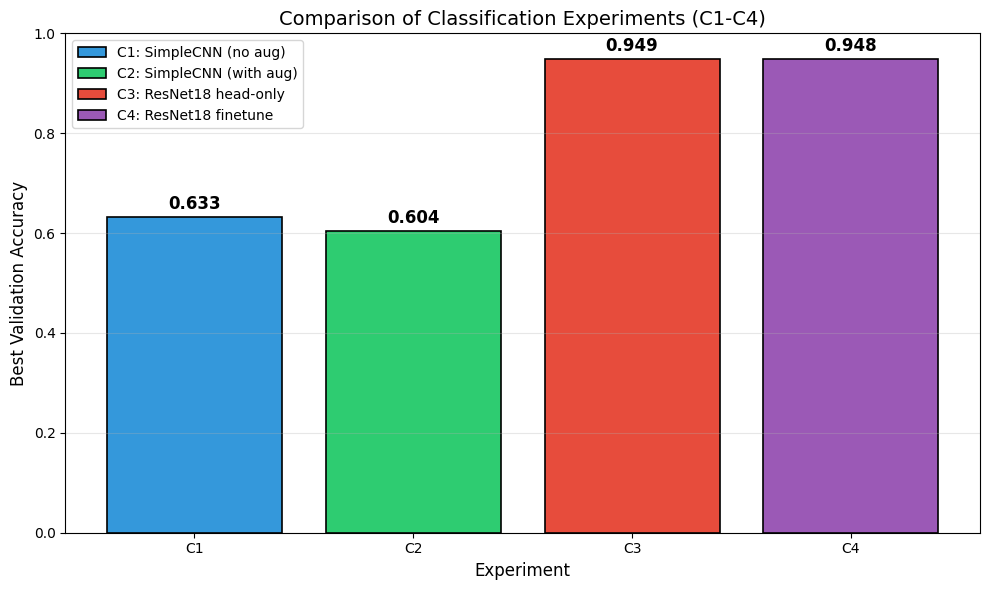

Saved: artifacts/figures/classification_compare.png


In [18]:
# Сравнение C1-C4 (bar plot)
fig, ax = plt.subplots(figsize=(10, 6))

experiments = list(results.keys())
accuracies = [results[exp] for exp in experiments]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = ax.bar(experiments, accuracies, color=colors, edgecolor='black', linewidth=1.2)

# Добавляем значения на столбцы
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.annotate(f'{acc:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Experiment', fontsize=12)
ax.set_ylabel('Best Validation Accuracy', fontsize=12)
ax.set_title('Comparison of Classification Experiments (C1-C4)', fontsize=14)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Добавляем легенду
labels = [
    'C1: SimpleCNN (no aug)',
    'C2: SimpleCNN (with aug)',
    'C3: ResNet18 head-only',
    'C4: ResNet18 finetune'
]
ax.legend(bars, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(figures_dir / 'classification_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {figures_dir / 'classification_compare.png'}")

## 9. Финальная оценка на test (Часть A)

In [20]:
# Загружаем лучшую модель и оцениваем на test
print("="*60)
print("Финальная оценка лучшего классификатора на test")
print("="*60)

# Определяем тип лучшей модели и создаём соответствующую архитектуру
if best_exp in ['C1', 'C2']:
    final_model = SimpleCNN(num_classes=STL10_NUM_CLASSES)
    _, _, test_loader_final = create_stl10_loaders(
        transform_base, transform_base, transform_base
    )
elif best_exp == 'C3':
    final_model = create_resnet18_head_only(num_classes=STL10_NUM_CLASSES)
    _, _, test_loader_final = create_stl10_loaders(
        transform_resnet, transform_resnet, transform_resnet
    )
else:  # C4
    final_model = create_resnet18_finetune(num_classes=STL10_NUM_CLASSES)
    _, _, test_loader_final = create_stl10_loaders(
        transform_resnet, transform_resnet, transform_resnet
    )

# Загружаем веса
final_model.load_state_dict(torch.load(BEST_CLASSIFIER_PATH, map_location=device))
final_model = final_model.to(device)

# Оцениваем на test
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(final_model, test_loader_final, criterion, device)

print(f"\nBest experiment: {best_exp}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Определяем transforms для конфига
transforms_info = {
    'C1': {'preprocess': 'ToTensor, Normalize(ImageNet)', 'augmentation': 'none'},
    'C2': {'preprocess': 'ToTensor, Normalize(ImageNet)', 'augmentation': 'HorizontalFlip(0.5), Rotation(15), ColorJitter(0.2,0.2,0.2)'},
    'C3': {'preprocess': 'Resize(224), ToTensor, Normalize(ImageNet)', 'augmentation': 'none'},
    'C4': {'preprocess': 'Resize(224), ToTensor, Normalize(ImageNet)', 'augmentation': 'HorizontalFlip(0.5), Rotation(15), ColorJitter(0.2,0.2,0.2)'}
}

# Обновляем конфиг с test accuracy и transforms
config = json.loads(BEST_CLASSIFIER_CONFIG_PATH.read_text(encoding='utf-8'))
config['test_accuracy'] = test_acc
config['transforms'] = transforms_info[best_exp]['preprocess']
config['augmentation'] = transforms_info[best_exp]['augmentation']
BEST_CLASSIFIER_CONFIG_PATH.write_text(
    json.dumps(config, indent=2, ensure_ascii=False),
    encoding='utf-8'
)
print(f"\nUpdated config with test_accuracy and transforms: {BEST_CLASSIFIER_CONFIG_PATH}")

# Обновляем runs.csv: добавляем test_accuracy для лучшего классификатора
import csv as csv_module
rows = []
with open(RUNS_CSV, 'r', encoding='utf-8') as f:
    reader = csv_module.reader(f)
    header = next(reader)
    rows.append(header)
    for row in reader:
        if row[0] == best_exp:
            # test_accuracy — колонка 9 (индекс 9)
            row[9] = str(test_acc)
        rows.append(row)

with open(RUNS_CSV, 'w', newline='', encoding='utf-8') as f:
    writer = csv_module.writer(f)
    writer.writerows(rows)

print(f"Updated runs.csv with test_accuracy={test_acc:.4f} for {best_exp}")

Финальная оценка лучшего классификатора на test

Best experiment: C3
Test Loss: 0.1727
Test Accuracy: 0.9434

Updated config with test_accuracy and transforms: artifacts/best_classifier_config.json
Updated runs.csv with test_accuracy=0.9434 for C3


---

# Часть B (S11): Сегментация на OxfordIIITPet

## 10. Данные для сегментации

In [21]:
# Загружаем OxfordIIITPet для сегментации
# В этом датасете маска имеет значения:
# 1 = foreground (pet)
# 2 = background
# 3 = border/boundary

class OxfordPetSegmentation(torch.utils.data.Dataset):
    """
    Обёртка для OxfordIIITPet с корректной обработкой масок.
    """
    def __init__(self, root, split='trainval', transform=None, target_size=(256, 256)):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=True
        )
        self.transform = transform
        self.target_size = target_size
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        
        # Resize изображения
        img = img.resize(self.target_size, Image.BILINEAR)
        mask = mask.resize(self.target_size, Image.NEAREST)
        
        # Конвертируем маску в numpy и создаём бинарную маску
        # 1 = pet (foreground), 2 = background, 3 = border
        # Мы считаем foreground = 1 (pet)
        mask_np = np.array(mask)
        # Бинарная маска: 1 где pet, 0 где background или border
        binary_mask = (mask_np == 1).astype(np.float32)
        
        # Применяем transform к изображению
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        
        # Маска как тензор
        mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0)  # (1, H, W)
        
        return img, mask_tensor


# Transform для сегментации (DeepLabV3 ожидает ImageNet нормализацию)
seg_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Создаём датасет
seg_dataset = OxfordPetSegmentation(
    root=data_root,
    split='trainval',
    transform=seg_transform,
    target_size=(256, 256)
)

print(f"OxfordIIITPet dataset size: {len(seg_dataset)}")

# Берём подмножество для валидации (первые 200 изображений)
seg_val_indices = list(range(200))
seg_val_dataset = Subset(seg_dataset, seg_val_indices)
seg_val_loader = DataLoader(seg_val_dataset, batch_size=8, shuffle=False)

# Sanity check
img_sample, mask_sample = seg_dataset[0]
print(f"Image shape: {img_sample.shape}")
print(f"Mask shape: {mask_sample.shape}")
print(f"Mask unique values: {torch.unique(mask_sample)}")

OxfordIIITPet dataset size: 3680
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Mask unique values: tensor([0., 1.])


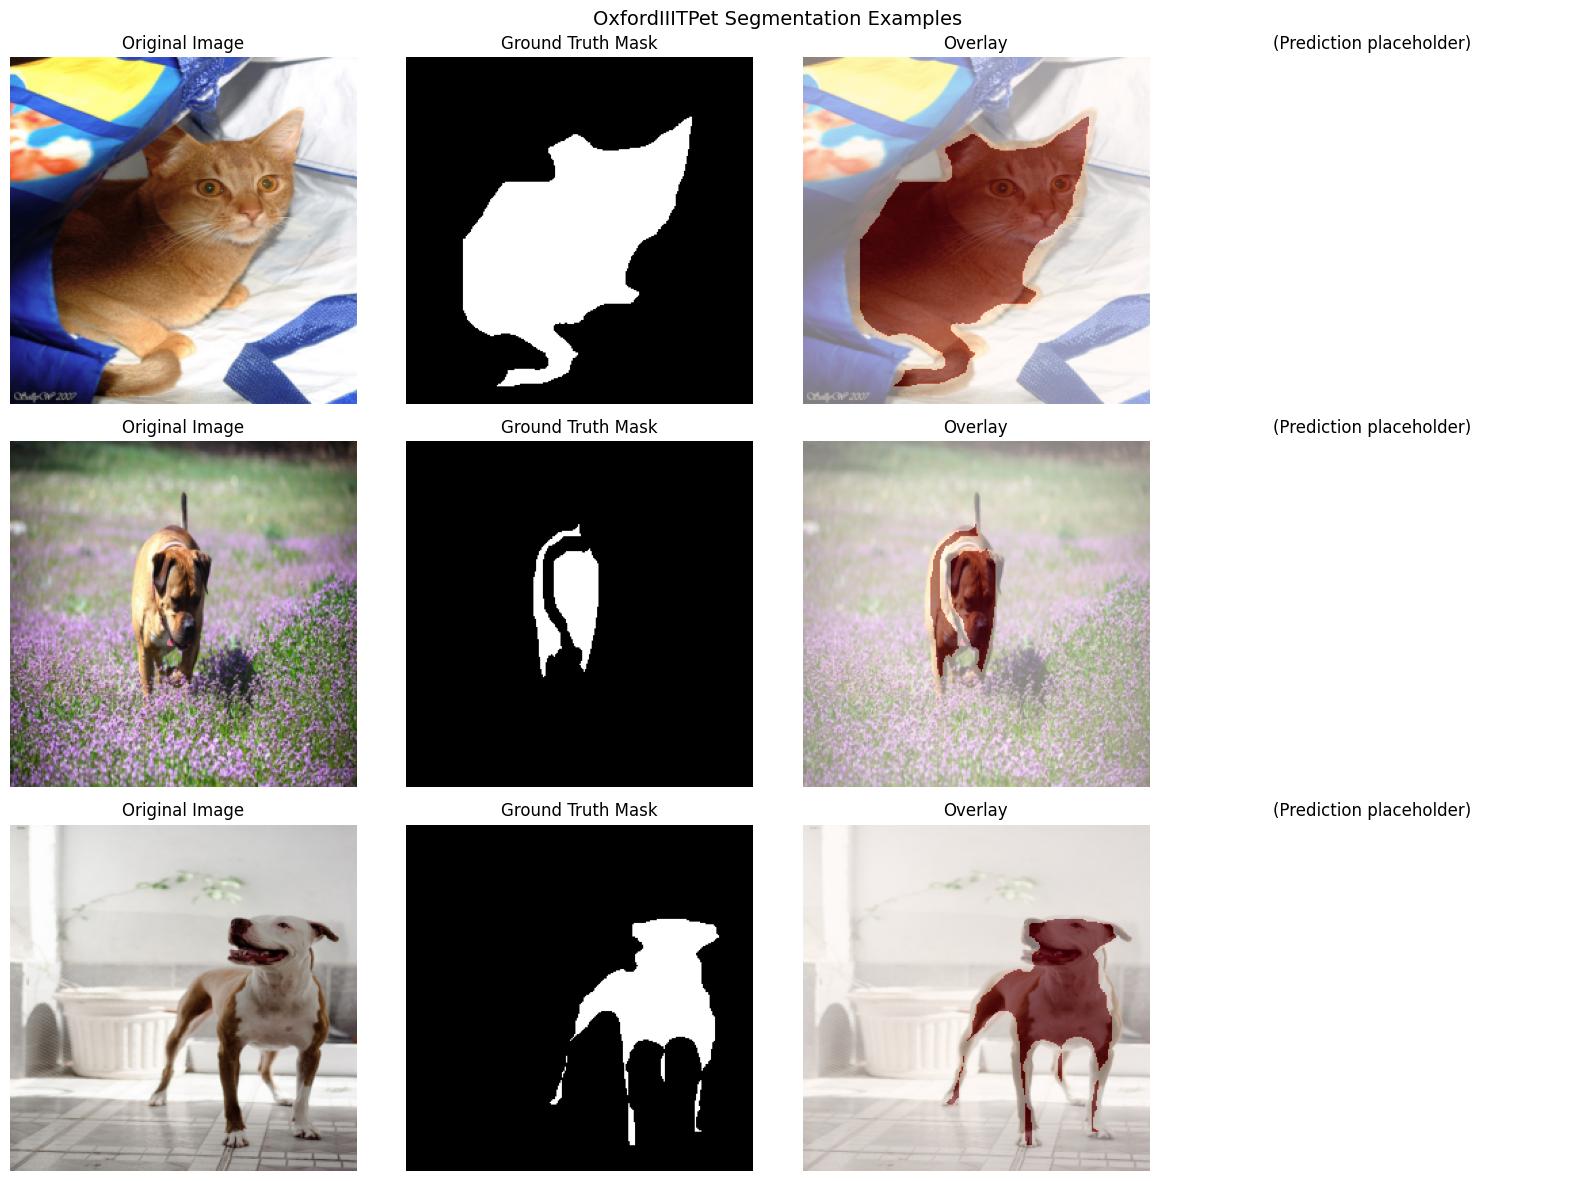

In [22]:
# Визуализация примеров сегментации
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(3):
    img, mask = seg_dataset[i * 50]  # Берём разные примеры
    
    # Денормализация изображения
    img_show = denormalize(img).permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0, 1)
    
    # Маска
    mask_show = mask.squeeze().numpy()
    
    axes[i, 0].imshow(img_show)
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask_show, cmap='gray')
    axes[i, 1].set_title('Ground Truth Mask')
    axes[i, 1].axis('off')
    
    # Overlay
    axes[i, 2].imshow(img_show)
    axes[i, 2].imshow(mask_show, cmap='Reds', alpha=0.5)
    axes[i, 2].set_title('Overlay')
    axes[i, 2].axis('off')
    
    # Placeholder для predicted mask (заполним позже)
    axes[i, 3].axis('off')
    axes[i, 3].set_title('(Prediction placeholder)')

plt.suptitle('OxfordIIITPet Segmentation Examples', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Модель сегментации и метрики

In [23]:
# Загружаем pretrained DeepLabV3
seg_model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
seg_model = seg_model.to(device)
seg_model.eval()

print("DeepLabV3_ResNet50 loaded successfully")
print(f"Number of output classes: {seg_model.classifier[-1].out_channels}")

DeepLabV3_ResNet50 loaded successfully
Number of output classes: 21


In [24]:
def compute_segmentation_metrics(pred_mask, gt_mask):
    """
    Вычисляет метрики сегментации.
    pred_mask, gt_mask: бинарные маски (0 или 1)
    
    Returns:
        dict с IoU, precision, recall
    """
    pred = pred_mask.flatten().astype(bool)
    gt = gt_mask.flatten().astype(bool)
    
    # True Positives, False Positives, False Negatives
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    
    # IoU = TP / (TP + FP + FN)
    union = tp + fp + fn
    iou = tp / union if union > 0 else 0.0
    
    # Precision = TP / (TP + FP)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    # Recall = TP / (TP + FN)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    return {
        'iou': iou,
        'precision': precision,
        'recall': recall
    }


@torch.no_grad()
def predict_segmentation(model, image, target_size=(256, 256)):
    """
    Получает предсказание сегментации от DeepLabV3.
    Возвращает маску вероятностей для класса с наибольшей активацией.
    """
    model.eval()
    
    if image.dim() == 3:
        image = image.unsqueeze(0)
    
    image = image.to(device)
    output = model(image)['out']  # (B, num_classes, H, W)
    
    # Softmax для получения вероятностей
    probs = F.softmax(output, dim=1)
    
    # Resize до целевого размера
    probs = F.interpolate(probs, size=target_size, mode='bilinear', align_corners=False)
    
    return probs.cpu()


def postprocess_v1(probs, foreground_threshold=0.5):
    """
    V1: Базовая постобработка.
    - Берём argmax по классам
    - Считаем foreground все классы кроме background (класс 0)
    """
    # Берём argmax по классам (класс 0 = background)
    pred_class = probs.argmax(dim=1)  # (B, H, W)
    
    # Foreground = любой класс кроме background
    foreground_mask = (pred_class != 0).float()
    
    return foreground_mask.squeeze().numpy()


def postprocess_v2(probs, foreground_threshold=0.5, min_area=500):
    """
    V2: Альтернативная постобработка с морфологической очисткой.
    - Аналогично V1, но дополнительно:
    - Применяем морфологическое открытие для удаления шума
    - Удаляем малые компоненты связности
    """
    # Базовая маска как в V1
    pred_class = probs.argmax(dim=1)
    foreground_mask = (pred_class != 0).float().squeeze().numpy()
    
    # Морфологическое открытие (erosion + dilation) для удаления шума
    structure = np.ones((3, 3))
    cleaned = ndimage.binary_opening(foreground_mask, structure=structure)
    
    # Удаление малых компонент связности
    labeled, num_features = ndimage.label(cleaned)
    
    if num_features > 0:
        # Находим размеры компонент
        component_sizes = ndimage.sum(cleaned, labeled, range(1, num_features + 1))
        
        # Оставляем только компоненты >= min_area
        mask = np.zeros_like(cleaned)
        for i, size in enumerate(component_sizes, 1):
            if size >= min_area:
                mask[labeled == i] = 1
        
        cleaned = mask
    
    return cleaned.astype(np.float32)


print("Segmentation functions defined.")

Segmentation functions defined.


## 12. Эксперименты V1 и V2 (Часть B)

In [25]:
# Запускаем оценку на валидационном наборе
print("="*60)
print("V1: Базовая постобработка")
print("="*60)

metrics_v1 = {'iou': [], 'precision': [], 'recall': []}

for i, (img, gt_mask) in enumerate(seg_val_loader):
    for j in range(img.shape[0]):
        single_img = img[j]
        single_gt = gt_mask[j].squeeze().numpy()
        
        # Предсказание
        probs = predict_segmentation(seg_model, single_img)
        pred_mask = postprocess_v1(probs)
        
        # Метрики
        m = compute_segmentation_metrics(pred_mask, single_gt)
        metrics_v1['iou'].append(m['iou'])
        metrics_v1['precision'].append(m['precision'])
        metrics_v1['recall'].append(m['recall'])

mean_iou_v1 = np.mean(metrics_v1['iou'])
mean_precision_v1 = np.mean(metrics_v1['precision'])
mean_recall_v1 = np.mean(metrics_v1['recall'])

print(f"V1 Results on {len(metrics_v1['iou'])} samples:")
print(f"  Mean IoU: {mean_iou_v1:.4f}")
print(f"  Mean Precision: {mean_precision_v1:.4f}")
print(f"  Mean Recall: {mean_recall_v1:.4f}")

# Логируем в CSV
log_to_csv(
    experiment_id='V1',
    task='segmentation',
    dataset='OxfordIIITPet',
    seed=SEED,
    model_summary='DeepLabV3_ResNet50 pretrained',
    optimizer_name='N/A',
    lr='',
    epochs_trained=0,
    best_val_accuracy=None,
    precision=mean_precision_v1,
    recall=mean_recall_v1,
    mean_iou=mean_iou_v1,
    notes='Basic postprocessing: argmax, foreground=non-background'
)

V1: Базовая постобработка
V1 Results on 200 samples:
  Mean IoU: 0.6696
  Mean Precision: 0.6754
  Mean Recall: 0.9896


In [26]:
print("="*60)
print("V2: Альтернативная постобработка (морфология + фильтрация)")
print("="*60)

metrics_v2 = {'iou': [], 'precision': [], 'recall': []}

for i, (img, gt_mask) in enumerate(seg_val_loader):
    for j in range(img.shape[0]):
        single_img = img[j]
        single_gt = gt_mask[j].squeeze().numpy()
        
        # Предсказание
        probs = predict_segmentation(seg_model, single_img)
        pred_mask = postprocess_v2(probs, min_area=500)
        
        # Метрики
        m = compute_segmentation_metrics(pred_mask, single_gt)
        metrics_v2['iou'].append(m['iou'])
        metrics_v2['precision'].append(m['precision'])
        metrics_v2['recall'].append(m['recall'])

mean_iou_v2 = np.mean(metrics_v2['iou'])
mean_precision_v2 = np.mean(metrics_v2['precision'])
mean_recall_v2 = np.mean(metrics_v2['recall'])

print(f"V2 Results on {len(metrics_v2['iou'])} samples:")
print(f"  Mean IoU: {mean_iou_v2:.4f}")
print(f"  Mean Precision: {mean_precision_v2:.4f}")
print(f"  Mean Recall: {mean_recall_v2:.4f}")

# Логируем в CSV
log_to_csv(
    experiment_id='V2',
    task='segmentation',
    dataset='OxfordIIITPet',
    seed=SEED,
    model_summary='DeepLabV3_ResNet50 pretrained',
    optimizer_name='N/A',
    lr='',
    epochs_trained=0,
    best_val_accuracy=None,
    precision=mean_precision_v2,
    recall=mean_recall_v2,
    mean_iou=mean_iou_v2,
    notes='Morphological cleaning + small component removal (min_area=500)'
)

V2: Альтернативная постобработка (морфология + фильтрация)
V2 Results on 200 samples:
  Mean IoU: 0.6706
  Mean Precision: 0.6764
  Mean Recall: 0.9894


## 13. Визуализация результатов сегментации

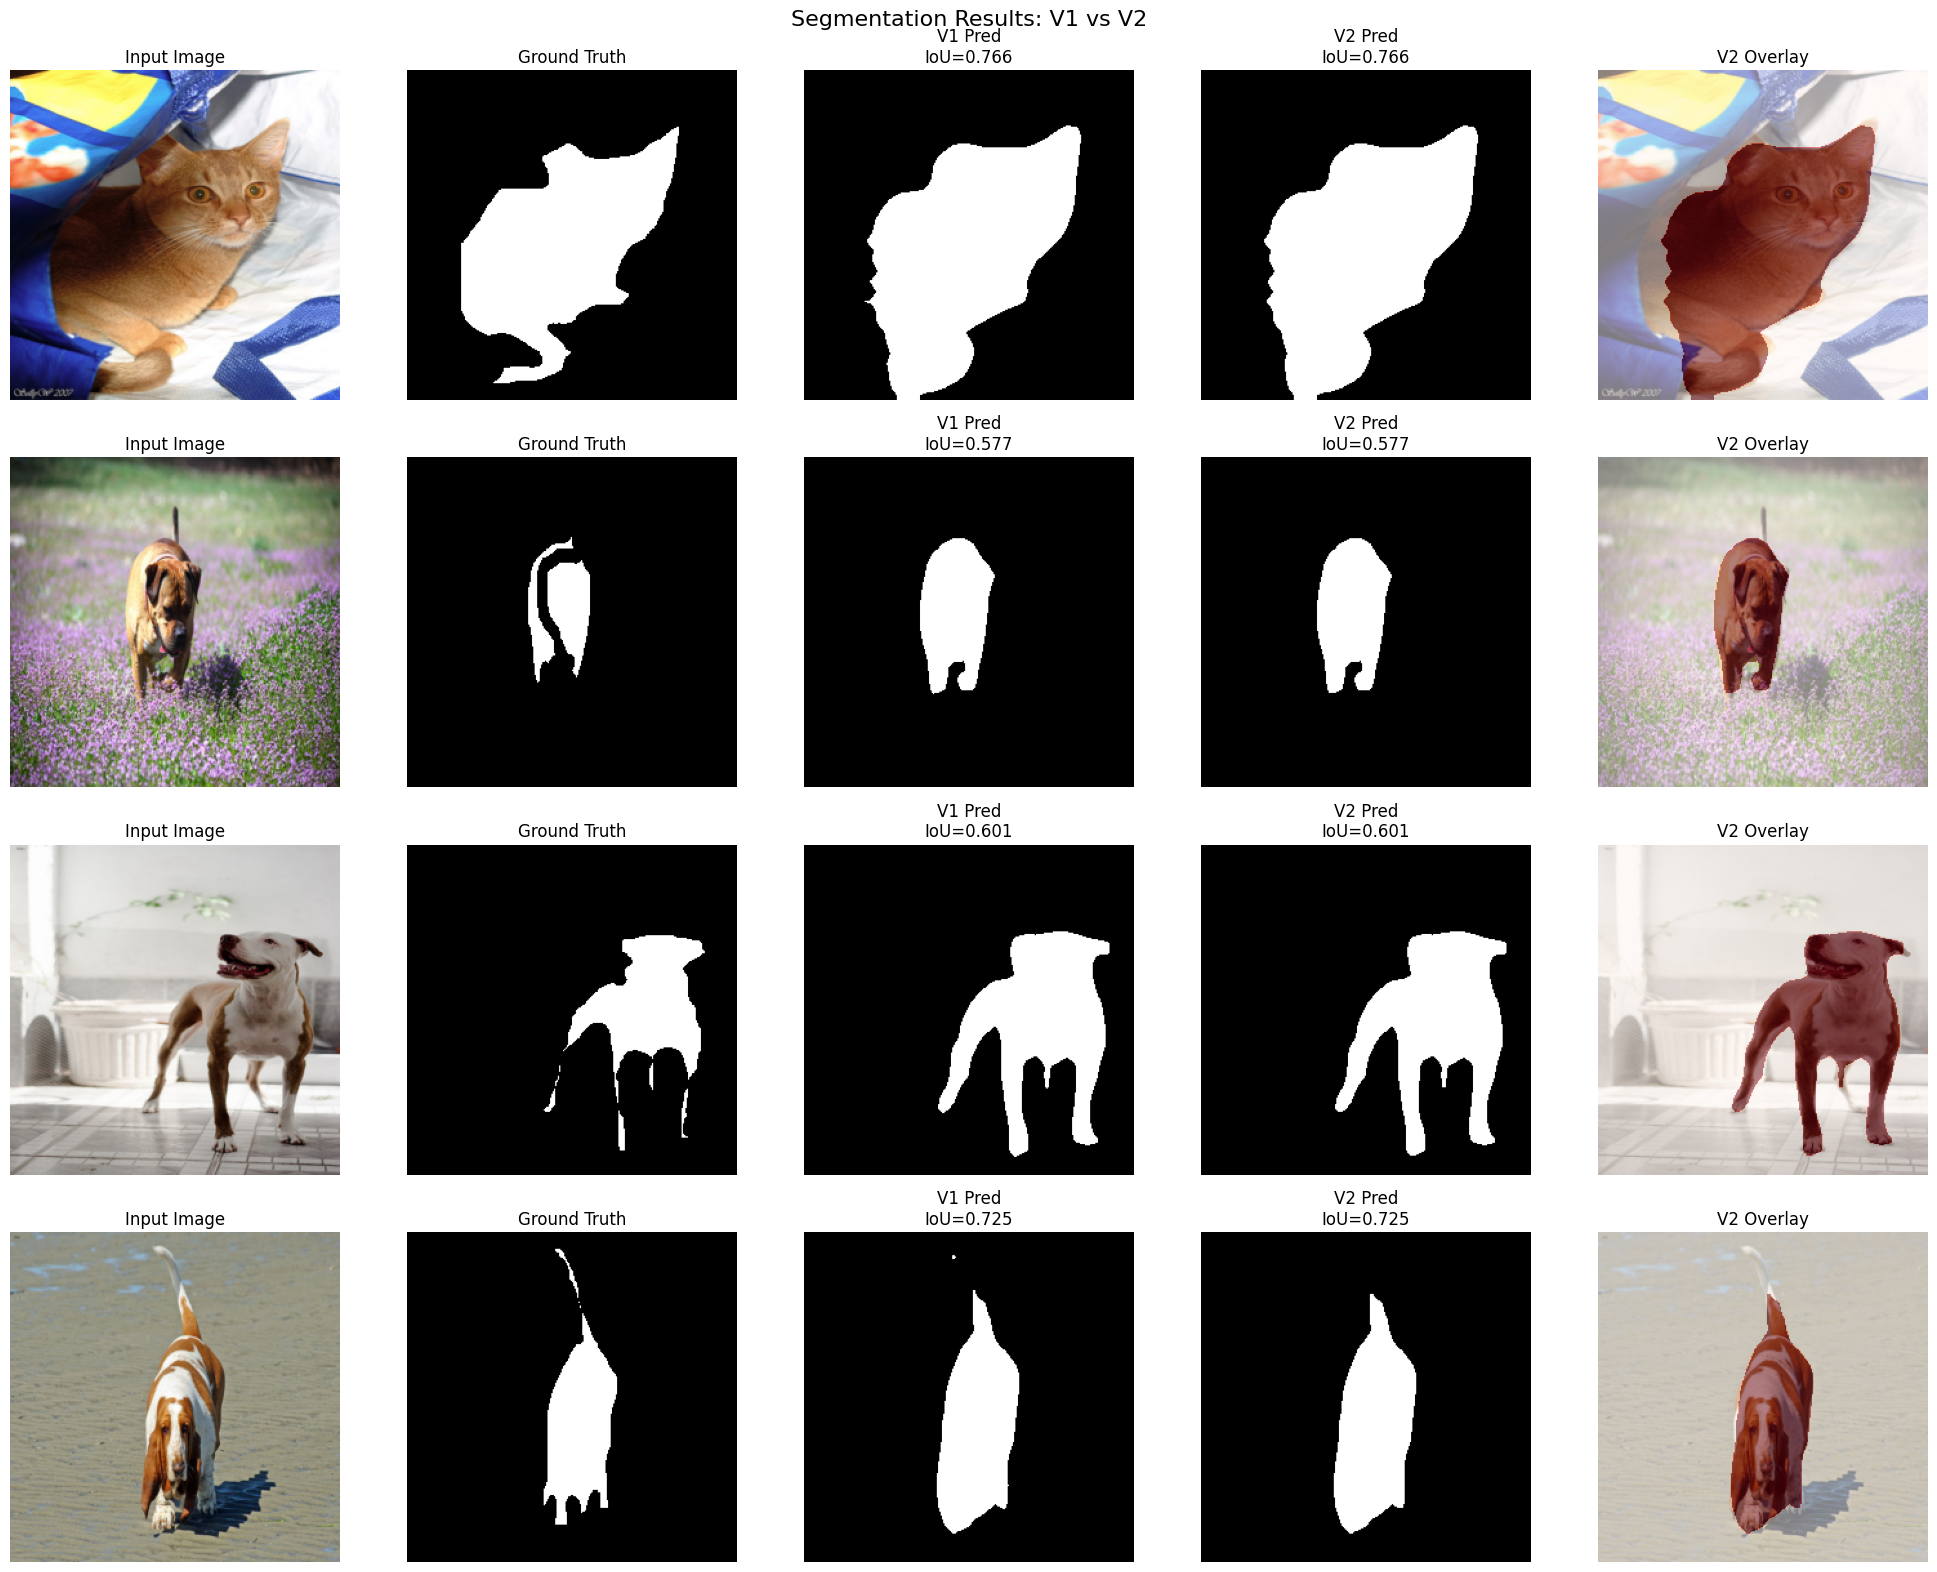

Saved: artifacts/figures/segmentation_examples.png


In [27]:
# Визуализация примеров сегментации V1 vs V2
fig, axes = plt.subplots(4, 5, figsize=(20, 16))

sample_indices = [0, 50, 100, 150]

for row, idx in enumerate(sample_indices):
    img, gt_mask = seg_dataset[idx]
    
    # Предсказания
    probs = predict_segmentation(seg_model, img)
    pred_v1 = postprocess_v1(probs)
    pred_v2 = postprocess_v2(probs, min_area=500)
    
    # Денормализация
    img_show = denormalize(img).permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0, 1)
    gt_show = gt_mask.squeeze().numpy()
    
    # Метрики для этого примера
    m_v1 = compute_segmentation_metrics(pred_v1, gt_show)
    m_v2 = compute_segmentation_metrics(pred_v2, gt_show)
    
    # Отображение
    axes[row, 0].imshow(img_show)
    axes[row, 0].set_title('Input Image')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(gt_show, cmap='gray')
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(pred_v1, cmap='gray')
    axes[row, 2].set_title(f'V1 Pred\nIoU={m_v1["iou"]:.3f}')
    axes[row, 2].axis('off')
    
    axes[row, 3].imshow(pred_v2, cmap='gray')
    axes[row, 3].set_title(f'V2 Pred\nIoU={m_v2["iou"]:.3f}')
    axes[row, 3].axis('off')
    
    # Overlay V2
    axes[row, 4].imshow(img_show)
    axes[row, 4].imshow(pred_v2, cmap='Reds', alpha=0.5)
    axes[row, 4].set_title('V2 Overlay')
    axes[row, 4].axis('off')

plt.suptitle('Segmentation Results: V1 vs V2', fontsize=16)
plt.tight_layout()
plt.savefig(figures_dir / 'segmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {figures_dir / 'segmentation_examples.png'}")

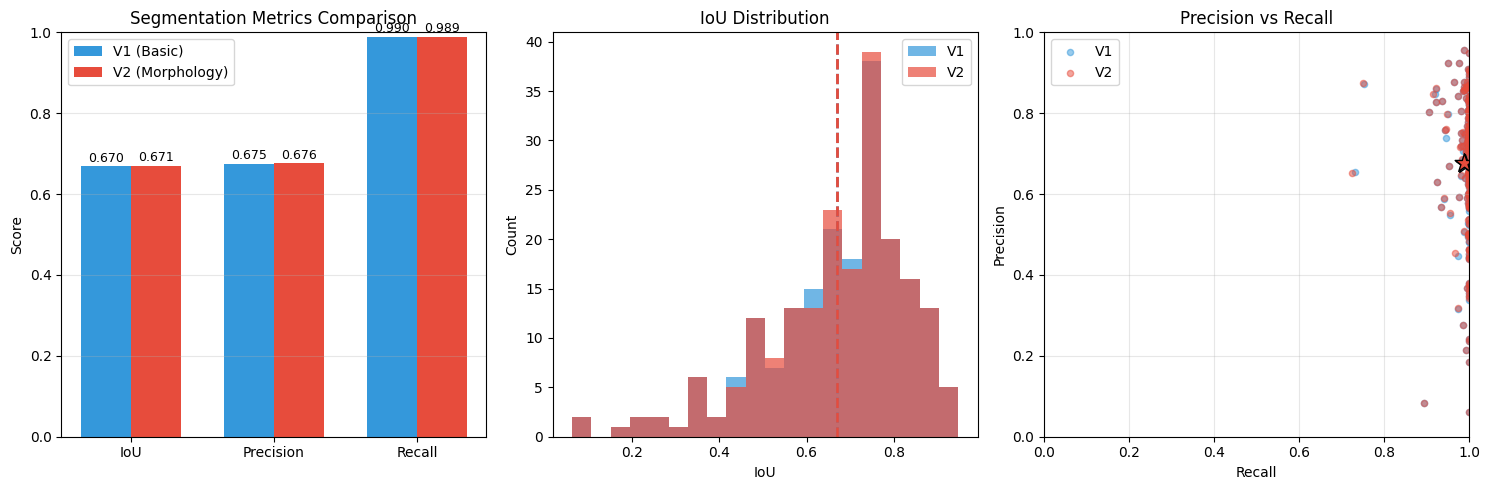

Saved: artifacts/figures/segmentation_metrics.png


In [28]:
# Сравнение метрик V1 vs V2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_names = ['IoU', 'Precision', 'Recall']
v1_values = [mean_iou_v1, mean_precision_v1, mean_recall_v1]
v2_values = [mean_iou_v2, mean_precision_v2, mean_recall_v2]

x = np.arange(len(metrics_names))
width = 0.35

# Bar plot
ax = axes[0]
bars1 = ax.bar(x - width/2, v1_values, width, label='V1 (Basic)', color='#3498db')
bars2 = ax.bar(x + width/2, v2_values, width, label='V2 (Morphology)', color='#e74c3c')

ax.set_ylabel('Score')
ax.set_title('Segmentation Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Добавляем значения
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

# IoU distribution
ax = axes[1]
ax.hist(metrics_v1['iou'], bins=20, alpha=0.7, label='V1', color='#3498db')
ax.hist(metrics_v2['iou'], bins=20, alpha=0.7, label='V2', color='#e74c3c')
ax.axvline(mean_iou_v1, color='#3498db', linestyle='--', linewidth=2)
ax.axvline(mean_iou_v2, color='#e74c3c', linestyle='--', linewidth=2)
ax.set_xlabel('IoU')
ax.set_ylabel('Count')
ax.set_title('IoU Distribution')
ax.legend()

# Precision-Recall scatter
ax = axes[2]
ax.scatter(metrics_v1['recall'], metrics_v1['precision'], alpha=0.5, label='V1', color='#3498db', s=20)
ax.scatter(metrics_v2['recall'], metrics_v2['precision'], alpha=0.5, label='V2', color='#e74c3c', s=20)
ax.scatter(mean_recall_v1, mean_precision_v1, marker='*', s=200, color='#3498db', edgecolors='black')
ax.scatter(mean_recall_v2, mean_precision_v2, marker='*', s=200, color='#e74c3c', edgecolors='black')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'segmentation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {figures_dir / 'segmentation_metrics.png'}")

## 14. Итоговая сводка

In [29]:
# Печатаем итоговую сводку
print("="*70)
print("ИТОГОВАЯ СВОДКА HW10-11")
print("="*70)

print("\n--- ЧАСТЬ A: Классификация (STL10) ---")
print(f"\nРезультаты экспериментов C1-C4:")
for exp_id in ['C1', 'C2', 'C3', 'C4']:
    print(f"  {exp_id}: val_accuracy = {results[exp_id]:.4f}")

print(f"\nЛучший эксперимент: {best_exp}")
print(f"Лучшая val_accuracy: {results[best_exp]:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

print(f"\nЭффект аугментаций (C2 vs C1): {results['C2'] - results['C1']:+.4f}")
print(f"Эффект transfer learning head-only (C3 vs C1): {results['C3'] - results['C1']:+.4f}")
print(f"Эффект fine-tuning (C4 vs C3): {results['C4'] - results['C3']:+.4f}")

print("\n--- ЧАСТЬ B: Сегментация (OxfordIIITPet) ---")
print(f"\nV1 (базовая постобработка):")
print(f"  Mean IoU: {mean_iou_v1:.4f}")
print(f"  Precision: {mean_precision_v1:.4f}")
print(f"  Recall: {mean_recall_v1:.4f}")

print(f"\nV2 (морфология + фильтрация):")
print(f"  Mean IoU: {mean_iou_v2:.4f}")
print(f"  Precision: {mean_precision_v2:.4f}")
print(f"  Recall: {mean_recall_v2:.4f}")

print(f"\nИзменение IoU (V2 vs V1): {mean_iou_v2 - mean_iou_v1:+.4f}")

print("\n--- АРТЕФАКТЫ ---")
print(f"  runs.csv: {RUNS_CSV}")
print(f"  best_classifier.pt: {BEST_CLASSIFIER_PATH}")
print(f"  best_classifier_config.json: {BEST_CLASSIFIER_CONFIG_PATH}")
print(f"  Figures: {figures_dir}/")

print("\n" + "="*70)
print("Ноутбук выполнен успешно!")
print("="*70)

ИТОГОВАЯ СВОДКА HW10-11

--- ЧАСТЬ A: Классификация (STL10) ---

Результаты экспериментов C1-C4:
  C1: val_accuracy = 0.6326
  C2: val_accuracy = 0.6045
  C3: val_accuracy = 0.9486
  C4: val_accuracy = 0.9480

Лучший эксперимент: C3
Лучшая val_accuracy: 0.9486
Test accuracy: 0.9434

Эффект аугментаций (C2 vs C1): -0.0281
Эффект transfer learning head-only (C3 vs C1): +0.3160
Эффект fine-tuning (C4 vs C3): -0.0006

--- ЧАСТЬ B: Сегментация (OxfordIIITPet) ---

V1 (базовая постобработка):
  Mean IoU: 0.6696
  Precision: 0.6754
  Recall: 0.9896

V2 (морфология + фильтрация):
  Mean IoU: 0.6706
  Precision: 0.6764
  Recall: 0.9894

Изменение IoU (V2 vs V1): +0.0010

--- АРТЕФАКТЫ ---
  runs.csv: artifacts/runs.csv
  best_classifier.pt: artifacts/best_classifier.pt
  best_classifier_config.json: artifacts/best_classifier_config.json
  Figures: artifacts/figures/

Ноутбук выполнен успешно!


In [30]:
# Проверяем содержимое runs.csv
print("\nСодержимое runs.csv:")
with open(RUNS_CSV, 'r', encoding='utf-8') as f:
    print(f.read())


Содержимое runs.csv:
experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
C1,classification,STL10,42,"SimpleCNN: Conv(3->32->64->128), FC(256), no augmentation",Adam,0.001,15,0.6326171867549419,,,,,Baseline CNN without augmentation
C2,classification,STL10,42,"SimpleCNN: Conv(3->32->64->128), FC(256), with augmentation",Adam,0.001,15,0.6044921875,,,,,"CNN with HorizontalFlip, Rotation, ColorJitter"
C3,classification,STL10,42,"ResNet18 pretrained, head-only (fc trainable)",Adam,0.001,15,0.9486328139901161,0.943375,,,,Transfer learning: only fc layer trained
C4,classification,STL10,42,"ResNet18 pretrained, partial finetune (layer4 + fc)",Adam,0.0001,15,0.9480468742549419,,,,,"Transfer learning: layer4 and fc trained, with augmentation"
V1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,N/A,,0,,,0.6753653816336903,0.9895645267875918,0.6696298566133642,"Basic postprocessing: argmax, foreground=